# Book Recommender System: Hybrid Content-Based & Collaborative Filtering

## 1. Problem Definition & Data Description

Membangun sistem rekomendasi buku(Book Recommender System) yang dipersonalisasi untuk memprediksi buku apa yang disukai oleh pengguna berdasarkan data yang relevan secara personal, dibagi menjadi 2 pendekatan utama:
1. **Masalah Utama**
      - **Prediksi Rating (Rating Prediction/regression)**: Memprediksi skor/rating yang akan diberikan oleh seorang pengguna ($u$) terhadap sebuah buku ($i$) yang belum pernah ia baca, berdasarkan pola rating dari pengguna lain.
      - **Rekomendasi Top-N (Item Recommendation / Ranking):** Menghasilkan daftar $N$ buku terbaik yang paling mungkin disukai atau dibaca oleh pengguna tertentu.
2. **Tantangan Spesifik Dataset Book-Crossing**
Dataset yang dikumpulkan oleh Cai-Nicolas Ziegler ini memiliki karakteristik unik yang menjadi bagian inti dari definisi masalahnya:
   1. **Pemisahan Implicit vs Explicit     Feedback**:
      - **Explicit Rating**: Rating bernilai 1–10 yang diberikan secara sadar oleh pengguna.
      - **Implicit Rating**: Rating bernilai 0, yang menunjukkan bahwa pengguna berinteraksi dengan buku tersebut (misalnya membaca/membeli) tetapi tidak memberikan nilai. Model harus mampu menangani interaksi implisit ini.
   2. **Data Sparsity (Data Sangat Jarang)**:
      Sebagian besar pengguna hanya memberi rating pada 1–2 buku, dan mayoritas buku hanya mendapat sedikit rating. Hal ini memicu masalah Cold Start (sulit memberikan rekomendasi untuk pengguna atau buku baru).
   3. **Ketidakseimbangan Data (Data Imbalance)**:
      Sebagian besar entri di dalam dataset bernilai 0 (implicit feedback), sehingga data explicit cukup terbatas.
3. **Struktur Input & Output Model**
      -  **Input**:
         -  User Data: User-ID, Location, Age.
         -  Book Data: ISBN, Book-Title, Book-Author, Year-Of-Publication, Publisher.
         -  Rating Data: User-ID, ISBN, Book-Rating (skala 0–10).
      - **Output**:
        - Skor prediksi rating atau daftar $N$ buku teratas yang dipersonalisasi untuk masing-masing pengguna.

**Pendekatan Solusi yang Biasa Digunakan**
- **Popularity-Based Filtering**: Memberikan rekomendasi buku paling populer (biasanya digunakan sebagai baseline atau untuk pengguna baru).
- **Collaborative Filtering**: Menggunakan matriks interaksi pengguna–buku (misal: SVD, KNN).
- **Content-Based Filtering** : Menggunakan metadata buku seperti nama penulis, judul, dan penerbit (misal: TF-IDF + Cosine Similarity).
- **Hybrid Systems**: Menggabungkan Collaborative dan Content-Based untuk mengatasai masalah Cold Start dan Sparsity.

## 2. Data Collection

### 2.1 Ekstrak dan Memuat Data
Langkah pertama adalah mengekstrak file dataset dari format `.zip`. Setelah diekstrak, kita memuat 3 file CSV utama menggunakan library `pandas` ke dalam bentuk DataFrame:
- `df_book_ratings`: Berisi data interaksi rating dari user untuk buku tertentu.
- `df_books`: Berisi informasi detail tentang buku (Judul, Penulis, Tahun Terbit, dll).
- `df_users`: Berisi data demografi pengguna (Lokasi dan Umur).

In [59]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("Book Crossing Dataset")
    print("Sukses")

Sukses


In [60]:
import pandas as pd
df_book_ratings = pd.read_csv("Book Crossing Dataset/BX-Book-Ratings.csv", sep=";", error_bad_lines=False, encoding="latin-1")
df_books = pd.read_csv("Book Crossing Dataset/BX-Books.csv", sep=";", error_bad_lines=False, encoding="latin-1")
df_users = pd.read_csv("Book Crossing Dataset/BX-Users.csv", sep=";", error_bad_lines=False, encoding="latin-1")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24872\745049328.py:2: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version. Use on_bad_lines in the future.


  df_book_ratings = pd.read_csv("Book Crossing Dataset/BX-Book-Ratings.csv", sep=";", error_bad_lines=False, encoding="latin-1")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24872\745049328.py:3: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version. Use on_bad_lines in the future.


  df_books = pd.read_csv("Book Crossing Dataset/BX-Books.csv", sep=";", error_bad_lines=False, encoding="latin-1")
Skipping line 6452: expected 8 fields, saw 9
Skipping line 43667: expected 8 fields, saw 10
Skipping line 51751: expected 8 fields, saw 9

Skipping line 92038: expected 8 fields, saw 9
Skipping line 104319: expected 8 fields, saw 9
Skipping line 121768: expected 8 fields, saw 9

Skipping line 144058: expected 8 fields, saw 9
Skipping line 150789:

## 3. Exploratory Data Analysis (EDA)

### 3.1 Inspeksi Awal Data
Pada tahap ini, kita melakukan inspeksi awal untuk "berkenalan" dengan data:
- `head()`: Melihat 5 baris pertama untuk memahami bentuk tabel.
- `shape`: Mengetahui ukuran data (jumlah baris dan kolom). Terlihat bahwa data rating memiliki lebih dari 1,1 juta baris!
- `info()`: Mengecek tipe data masing-masing kolom dan memastikan apakah ada nilai kosong secara sekilas.

In [61]:
print("5 Baris Pertama dari Dataset Books")
df_books.head()

5 Baris Pertama dari Dataset Books


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [62]:
print("5 Baris Pertama dari Dataset Book Ratings")
df_book_ratings.head()

5 Baris Pertama dari Dataset Book Ratings


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [63]:
print("5 Baris Pertama dari Dataset Users")
df_users.head()

5 Baris Pertama dari Dataset Users


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [64]:
df_books.shape, df_book_ratings.shape, df_users.shape

((271360, 8), (1149780, 3), (278858, 3))

In [65]:
print("===Informasi Dataset Books")
df_books.info()
print("===Informasi Dataset Book Ratings")
df_book_ratings.info()
print("===Informasi Dataset Users")
df_users.info()

===Informasi Dataset Books
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271359 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB
===Informasi Dataset Book Ratings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2  

#### Temuan: Ukuran & Struktur Data

Setelah melihat bentuk dan isi datanya, ada beberapa hal penting yang saya temukan:

**1. Ukuran data**
- `df_books`: 271.360 buku, 8 kolom informasi.
- `df_book_ratings`: 1.149.780 baris interaksi rating — cukup besar untuk melatih model collaborative filtering.
- `df_users`: 278.858 pengguna.

**2. Data yang kosong**
- Kolom `Age` di tabel Users paling banyak kosong: 110.762 dari 278.858 baris tidak mengisi umur.
- Di tabel Books, cuma beberapa baris yang kosong (Book-Author, Publisher, Image-URL-L) — jumlahnya kecil.
- Tabel Ratings tidak ada yang kosong sama sekali.

**3. Kolom tahun terbit bermasalah**
Kolom `Year-Of-Publication` seharusnya berisi angka, tapi tipe datanya `object` (teks) — indikasi kuat ada data yang salah tempat.

**4. Rating 0 itu bukan rating buruk**
Banyak baris di `Book-Rating` bernilai 0, menandakan implicit feedback, bukan rating eksplisit.

### 3.2 Missing Values, Duplikat & Data Unik
Kita perlu memastikan kebersihan data sebelum dilatih ke dalam model:
- Mengecek nilai yang hilang (missing value). Ditemukan banyak data umur (`Age`) yang kosong.
- Mengecek data duplikat (tidak ditemukan duplikat).
- Mengecek jumlah data unik (`nunique()`). Terlihat ada sekitar 105 ribu user unik dan 340 ribu buku unik.

In [66]:
print("===Jumlah Data Kosong pada Dataset Books")
print(df_books.isnull().sum())
print("===Jumlah Data Kosong pada Dataset Book Ratings")
print(df_book_ratings.isnull().sum())
print("===Jumlah Data Kosong pada Dataset Users")
print(df_users.isnull().sum())

===Jumlah Data Kosong pada Dataset Books
ISBN                   0
Book-Title             0
Book-Author            1
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64
===Jumlah Data Kosong pada Dataset Book Ratings
User-ID        0
ISBN           0
Book-Rating    0
dtype: int64
===Jumlah Data Kosong pada Dataset Users
User-ID          0
Location         0
Age         110762
dtype: int64


#### Temuan: Missing Value per Dataset

- Books: `Book-Author` (1 baris), `Publisher` (2 baris), `Image-URL-L` (3 baris) kosong.
- Users: `Age` kosong di 110.762 dari 278.858 baris.
- Book Ratings: tidak ada yang kosong.

In [67]:
print("===Jumlah Data Duplikasi pada Dataset Books")
print(df_books.duplicated().sum())
print("===Jumlah Data Duplikasi pada Dataset Book Ratings")
print(df_book_ratings.duplicated().sum())
print("===Jumlah Data Duplikasi pada Dataset Users")
print(df_users.duplicated().sum())

===Jumlah Data Duplikasi pada Dataset Books
0
===Jumlah Data Duplikasi pada Dataset Book Ratings
0
===Jumlah Data Duplikasi pada Dataset Users
0


In [68]:
print("===Jumlah Data Unik pada Dataset Books")
print(df_books.nunique())
print("===Jumlah Data Unik pada Dataset Book Ratings")
print(df_book_ratings.nunique())
print("===Jumlah Data Unik pada Dataset Users")
print(df_users.nunique())

===Jumlah Data Unik pada Dataset Books
ISBN                   271360
Book-Title             242135
Book-Author            102023
Year-Of-Publication       202
Publisher               16807
Image-URL-S            271044
Image-URL-M            271044
Image-URL-L            271041
dtype: int64
===Jumlah Data Unik pada Dataset Book Ratings
User-ID        105283
ISBN           340556
Book-Rating        11
dtype: int64
===Jumlah Data Unik pada Dataset Users
User-ID     278858
Location     57339
Age            165
dtype: int64


#### Temuan: Duplikat & Data Unik

**Duplikat**: ketiga tabel sama-sama 0 duplikat.

**Data unik**:
- Books: 271.360 ISBN unik vs 242.135 judul unik — satu judul bisa punya beberapa ISBN (beda edisi).
- Ratings: 340.556 ISBN unik pernah dirating — lebih banyak dari ISBN di Books (271.360), konfirmasi orphan ISBN.
- Dari 278.858 user terdaftar, cuma 105.283 yang benar-benar pernah memberi rating. Skala rating 0-10 (11 tingkat).

### 3.3 Anomali Kolom Year-Of-Publication

In [69]:
print(df_books['Year-Of-Publication'].unique())

[2002 2001 1991 1999 2000 1993 1996 1988 2004 1998 1994 2003 1997 1983
 1979 1995 1982 1985 1992 1986 1978 1980 1952 1987 1990 1981 1989 1984 0
 1968 1961 1958 1974 1976 1971 1977 1975 1965 1941 1970 1962 1973 1972
 1960 1966 1920 1956 1959 1953 1951 1942 1963 1964 1969 1954 1950 1967
 2005 1957 1940 1937 1955 1946 1936 1930 2011 1925 1948 1943 1947 1945
 1923 2020 1939 1926 1938 2030 1911 1904 1949 1932 1928 1929 1927 1931
 1914 2050 1934 1910 1933 1902 1924 1921 1900 2038 2026 1944 1917 1901
 2010 1908 1906 1935 1806 2021 '2000' '1995' '1999' '2004' '2003' '1990'
 '1994' '1986' '1989' '2002' '1981' '1993' '1983' '1982' '1976' '1991'
 '1977' '1998' '1992' '1996' '0' '1997' '2001' '1974' '1968' '1987' '1984'
 '1988' '1963' '1956' '1970' '1985' '1978' '1973' '1980' '1979' '1975'
 '1969' '1961' '1965' '1939' '1958' '1950' '1953' '1966' '1971' '1959'
 '1972' '1955' '1957' '1945' '1960' '1967' '1932' '1924' '1964' '2012'
 '1911' '1927' '1948' '1962' '2006' '1952' '1940' '1951' '1931' '1954

In [70]:
df_books[df_books['Year-Of-Publication'] == 'DK Publishing Inc']

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


In [71]:
non_numeric = df_books[~df_books['Year-Of-Publication'].astype(str).str.isnumeric()]
print(non_numeric.shape[0])
non_numeric.head()

3


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


#### Temuan: Data Shift & Nilai Tidak Valid

Saat cek nilai unik di `Year-Of-Publication`, ternyata isinya bukan cuma angka tahun — ada `'0'`, angka tersimpan sebagai teks, bahkan nama penerbit seperti `'DK Publishing Inc'` dan `'Gallimard'`.

Setelah difilter, ketahuan penyebabnya: datanya bergeser ke kanan. Tahun terbit yang benar (2000) masuk ke kolom `Book-Author`, nama penerbit masuk ke kolom `Year-Of-Publication`, link gambar masuk ke `Publisher`, dan `Image-URL-L` jadi kosong.

Total baris yang kena: **3 baris** (2 dari DK Publishing Inc, 1 dari Gallimard) — cukup sedikit untuk diperbaiki manual.

In [72]:
missing_isbn = ~df_book_ratings['ISBN'].isin(df_books['ISBN'])
missing_isbn.sum()

118644

### 3.4 Orphan ISBN pada Data Rating

#### Temuan: 118.644 Baris Orphan ISBN

Ada 118.644 baris di `df_book_ratings` yang ISBN-nya tidak terdaftar di `df_books` — rating untuk buku yang informasinya (judul, penulis, penerbit) tidak kita punya sama sekali.

Untuk content-based filtering, data ini tidak bisa dipakai. Untuk collaborative filtering, masih bisa dipakai karena CF cuma butuh ISBN sebagai ID.

In [73]:
print(df_users['Age'].describe())

df_users[(df_users['Age'] < 5) | (df_users['Age'] > 100)].shape[0]

count    168096.000000
mean         34.751434
std          14.428097
min           0.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         244.000000
Name: Age, dtype: float64


1248

### 3.5 Distribusi Umur Pengguna & Outlier

#### Temuan: Outlier Umur (1.248 baris)

Rata-rata umur user 34,7 tahun, median 32 tahun, sebagian besar (kuartil 1-3) di rentang 24-44 tahun.

Ada anomali: umur minimum 0 tahun, maksimum 244 tahun — jelas tidak masuk akal untuk manusia. Jumlah baris dengan umur di luar rentang wajar (di bawah 5 atau di atas 100): **1.248 baris**.

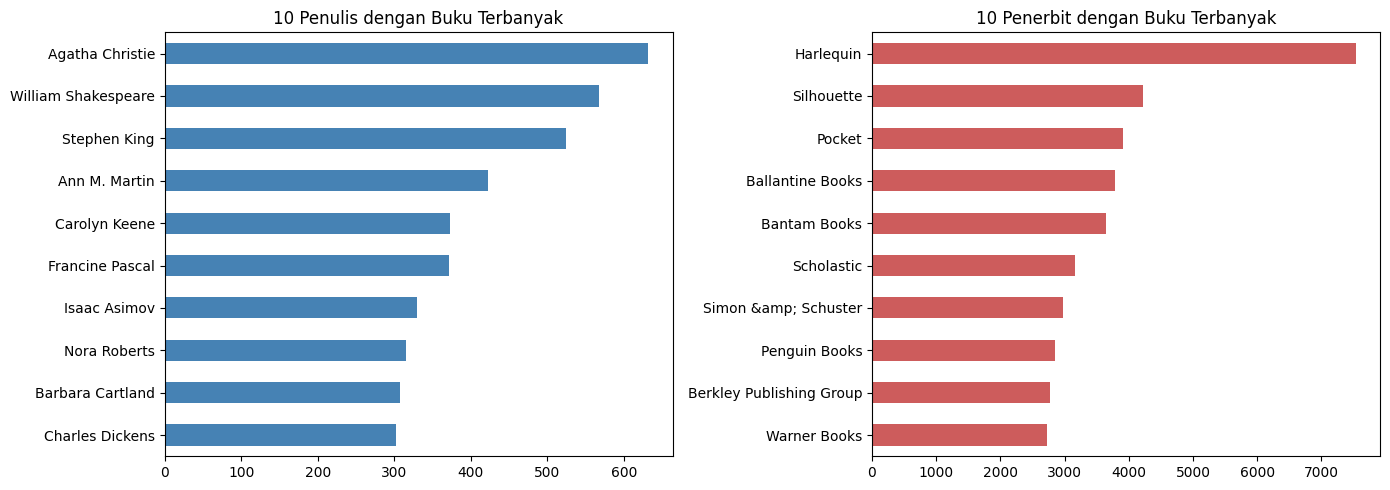

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,5))

df_books['Book-Author'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('10 Penulis dengan Buku Terbanyak')

df_books['Publisher'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='indianred')
axes[1].invert_yaxis()
axes[1].set_title('10 Penerbit dengan Buku Terbanyak')

plt.tight_layout()
plt.show()

### 3.6 Profil Buku: Penulis, Penerbit, & Statistik Umum

In [75]:
df_books.describe(include='all')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
count,271360,271360,271359,271360,271358,271360,271360,271357
unique,271360,242135,102023,202,16807,271044,271044,271041
top,0195153448,Selected Poems,Agatha Christie,2002,Harlequin,http://images.amazon.com/images/P/185326119X.0...,http://images.amazon.com/images/P/185326119X.0...,http://images.amazon.com/images/P/225307649X.0...
freq,1,27,632,13903,7535,2,2,2


In [76]:
df_book_ratings.describe(include='all')

,User-ID,ISBN,Book-Rating
count,1.149780e+06,1149780,1.149780e+06
unique,NaN,340556,NaN
top,NaN,0971880107,NaN
freq,NaN,2502,NaN
mean,1.403864e+05,NaN,2.866950e+00
std,8.056228e+04,NaN,3.854184e+00
min,2.000000e+00,NaN,0.000000e+00
25%,7.034500e+04,NaN,0.000000e+00
50%,1.410100e+05,NaN,0.000000e+00
75%,2.110280e+05,NaN,7.000000e+00


In [77]:
df_users.describe(include='all')

,User-ID,Location,Age
count,278858.00000,278858,168096.000000
unique,NaN,57339,NaN
top,NaN,"london, england, united kingdom",NaN
freq,NaN,2506,NaN
mean,139429.50000,NaN,34.751434
std,80499.51502,NaN,14.428097
min,1.00000,NaN,0.000000
25%,69715.25000,NaN,24.000000
50%,139429.50000,NaN,32.000000
75%,209143.75000,NaN,44.000000


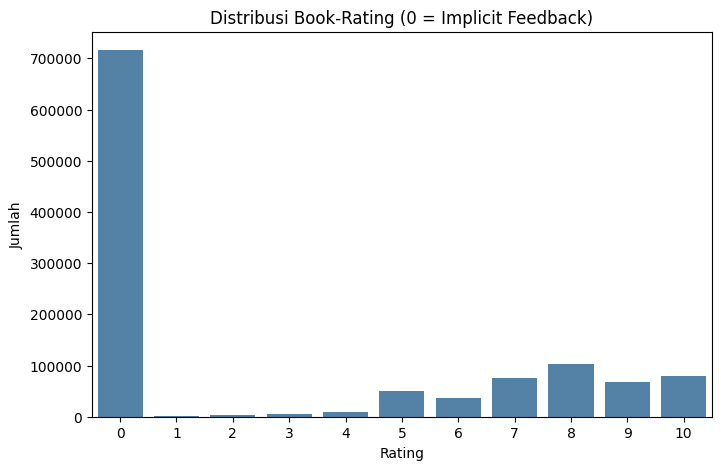

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Book-Rating', data=df_book_ratings, color='steelblue')
plt.title('Distribusi Book-Rating (0 = Implicit Feedback)')
plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.show()

#### Temuan: Statistik Deskriptif & Profil Penulis/Penerbit

**Books**: Penulis terbanyak Agatha Christie (632 buku), penerbit terbanyak Harlequin (7.535 buku). Judul "Selected Poems" muncul 27 kali dengan ISBN berbeda. Tahun terbit terbanyak: 2002 (13.903 buku).

**Book Ratings**: Buku paling banyak dirating adalah ISBN 0971880107 (2.502 kali). Rata-rata rating 2,86, median 0 — memperkuat dominasi implicit feedback.

**Users**: Lokasi terbanyak London, England, UK (2.506 user).

**Dari chart**: Agatha Christie di posisi pertama, diikuti William Shakespeare dan Stephen King. Harlequin jauh di atas penerbit lain, disusul Silhouette dan Pocket — dua nama teratas ini sama-sama penerbit novel romansa. Ada anomali kecil: label "Simon &amp; Schuster" menunjukkan karakter `&` belum ter-decode dari HTML entity, indikasi kolom `Publisher` masih butuh sedikit pembersihan teks lebih lanjut.

### 3.7 Distribusi Rating (Explicit vs Implicit)
Di dataset *Book-Crossing*, rating 0 bukan berarti bukunya jelek, melainkan **Implicit Feedback** (User membaca/membeli buku tersebut, tapi tidak memberikan nilai 1-10). Terlihat bahwa mayoritas interaksi di dataset ini adalah *implicit* (angka 0 sangat mendominasi). Grafik histogram di bawah membantu kita memvisualisasikan sebaran data numerik ini.

In [78]:
df_ratings = (df_book_ratings['Book-Rating'] == 0).sum()
print("Jumlah Data Rating dari 0:", df_ratings)

Jumlah Data Rating dari 0: 716109


In [79]:
print(df_book_ratings['Book-Rating'].value_counts())

0     716109
8     103736
10     78610
7      76457
9      67541
5      50974
6      36924
4       8904
3       5996
2       2759
1       1770
Name: Book-Rating, dtype: int64


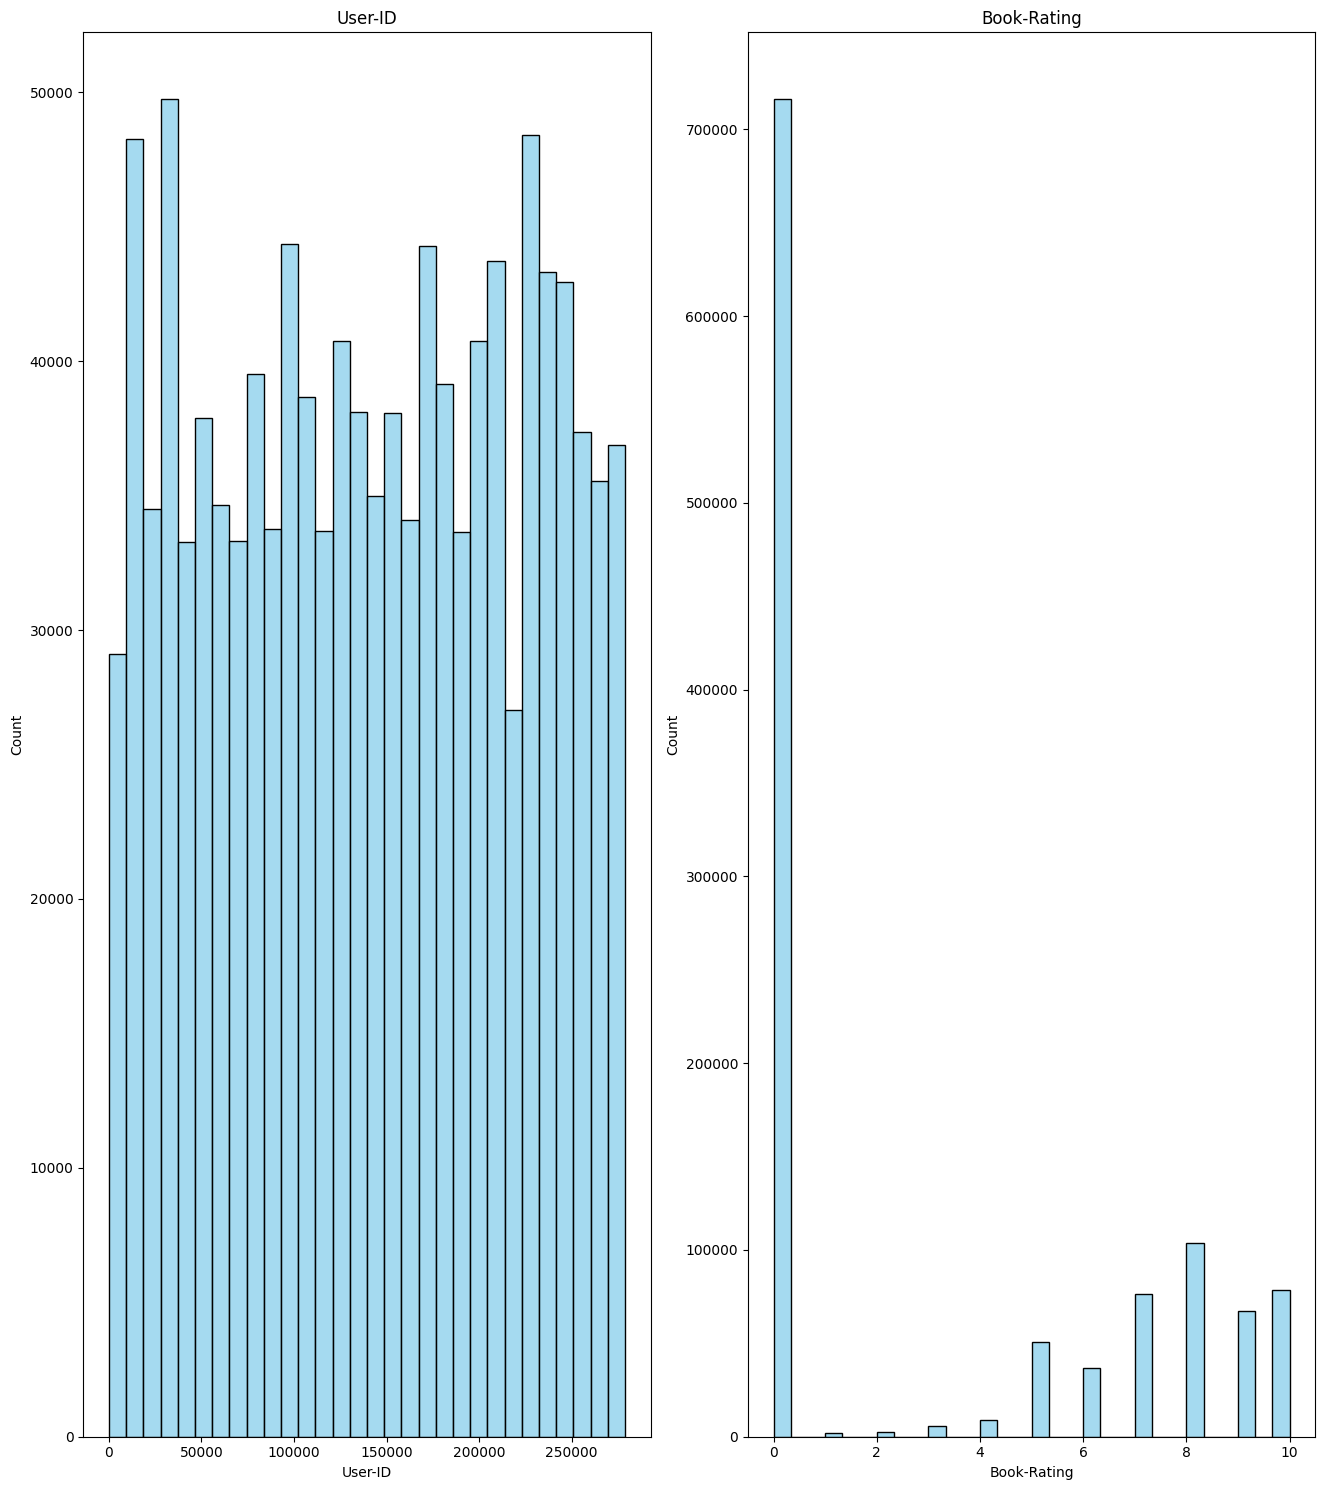

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

num_col = df_book_ratings.select_dtypes(include='number').columns
n_col = 3
n_row = (len(num_col)//n_col)+1
plt.figure(figsize=(20,15))

for i, col in enumerate(num_col, 1):
    plt.subplot(n_row, n_col, i)
    sns.histplot(df_book_ratings[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(col)

plt.tight_layout()
plt.show()

In [82]:
ratings_per_user = df_book_ratings.groupby('User-ID')['Book-Rating'].count().reset_index()
ratings_per_user.columns = ['User-ID', 'Jumlah_Rating']
print(ratings_per_user.head())

   User-ID  Jumlah_Rating
0        2              1
1        7              1
2        8             18
3        9              3
4       10              2


In [83]:
ratings_per_book = df_book_ratings.groupby('ISBN')['Book-Rating'].count().reset_index()
ratings_per_book.columns = ['ISBN', 'Jumlah_Rating' ]
print(ratings_per_book.head())

          ISBN  Jumlah_Rating
0   0330299891              2
1   0375404120              2
2   0586045007              1
3   9022906116              2
4   9032803328              1


#### Temuan: Dominasi Rating 0 (Implicit Feedback)

Ada 716.109 baris dengan rating 0 — mendominasi dataset. Untuk rating eksplisit (1-10), yang paling sering muncul justru angka tinggi: 8 (103.736 kali), 10 (78.610 kali), 7 (76.457 kali). Rating rendah jarang diberikan (rating 1 cuma 1.770 kali).

### 3.8 Long-Tail: Aktivitas User & Popularitas Buku

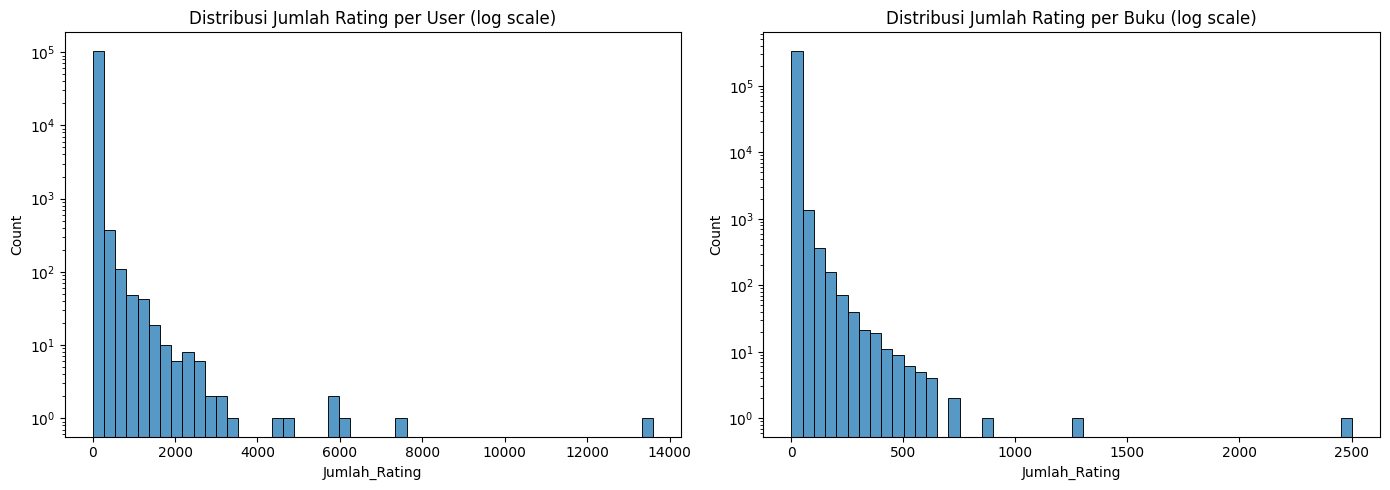

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(ratings_per_user['Jumlah_Rating'], bins=50, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Distribusi Jumlah Rating per User (log scale)')

sns.histplot(ratings_per_book['Jumlah_Rating'], bins=50, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Distribusi Jumlah Rating per Buku (log scale)')

plt.tight_layout()
plt.show()

#### Temuan: Pola Long-Tail

Dari `ratings_per_user` dan `ratings_per_book`, terlihat variasi besar — ada user yang cuma 1 rating, ada yang belasan ribu. Pola serupa di buku: banyak yang cuma 1-2 interaksi. Karena mayoritas user cuma baca sedikit buku dan mayoritas buku cuma dibaca sedikit orang, matriks user-item jadi sangat kosong (sparse).

### 3.9 Sparsity Matriks User-Item
Sistem rekomendasi bekerja dengan memetakan User ke Buku. *Sparsity* mengukur seberapa banyak sel yang kosong dalam pemetaan tersebut. Hasilnya adalah **99.99%**, yang berarti sangat wajar di dunia nyata karena satu pengguna tidak mungkin membaca semua buku yang ada. Namun, ini akan menjadi tantangan komputasi untuk model kita nanti.

In [85]:
n_users = df_book_ratings['User-ID'].nunique()
n_books = df_book_ratings['ISBN'].nunique()
n_ratings = df_book_ratings.shape[0]
sparsity = 1 - (n_ratings/(n_users*n_books))

print("Jumlah user :", n_users)
print("Jumlah Buju", n_books)
print("Jumlah Rating:", n_ratings)
print("Sparsity matriks user-item:", sparsity)

Jumlah user : 105283
Jumlah Buju 340556
Jumlah Rating: 1149780
Sparsity matriks user-item: 0.9999679322889055


#### Temuan: Sparsity 99,9967%

Matriks user-item (105.283 user × 340.556 buku) punya sparsity 0,999967 — hampir seluruh sel kosong, cuma sekitar 0,0033% yang terisi rating. Ini yang jadi alasan thresholding minimal rating per user/buku diterapkan sebelum masuk ke model SVD.

## 4. Data Cleaning & Preprocessing

### 4.1 Membersihkan Kolom Year-Of-Publication

Dari hasil eksplorasi sebelumnya, ada kesalahan penempatan data di mana nama penerbit ('DK Publishing Inc', 'Gallimard') masuk ke kolom Tahun Terbit. Kode di bawah ini mendeteksi dan memperbaiki nilai yang bukan angka.

In [86]:
mask_non_numeric = ~df_books['Year-Of-Publication'].astype(str).str.isnumeric()
indices = df_books[mask_non_numeric].index

for idx in indices:
    if str(df_books.loc[idx, 'Book-Author']).isdigit():
        df_books.loc[idx, 'Year-Of-Publication'] = df_books.loc[idx, 'Book-Author']
        df_books.loc[idx, 'Book-Author'] = None


In [87]:
non_numeric_new = df_books[~df_books['Year-Of-Publication'].astype(str).str.isnumeric()]
print(non_numeric_new.shape[0])
non_numeric_new.head()

0


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L


In [88]:
df_books['Year-Of-Publication'] = pd.to_numeric(df_books['Year-Of-Publication'], errors='coerce')
print(df_books['Year-Of-Publication'].head(10))
print("Jumlah NaN setelah konversi:", df_books['Year-Of-Publication'].isna().sum())

0    2002
1    2001
2    1991
3    1999
4    1999
5    1991
6    2000
7    1993
8    1996
9    2002
Name: Year-Of-Publication, dtype: int64
Jumlah NaN setelah konversi: 0


In [89]:
print(df_books['Year-Of-Publication'].unique())

[2002 2001 1991 1999 2000 1993 1996 1988 2004 1998 1994 2003 1997 1983
 1979 1995 1982 1985 1992 1986 1978 1980 1952 1987 1990 1981 1989 1984
    0 1968 1961 1958 1974 1976 1971 1977 1975 1965 1941 1970 1962 1973
 1972 1960 1966 1920 1956 1959 1953 1951 1942 1963 1964 1969 1954 1950
 1967 2005 1957 1940 1937 1955 1946 1936 1930 2011 1925 1948 1943 1947
 1945 1923 2020 1939 1926 1938 2030 1911 1904 1949 1932 1928 1929 1927
 1931 1914 2050 1934 1910 1933 1902 1924 1921 1900 2038 2026 1944 1917
 1901 2010 1908 1906 1935 1806 2021 2012 2006 1909 2008 1378 1919 1922
 1897 2024 1376 2037]


In [90]:
print(df_books['Year-Of-Publication'].value_counts().sort_index().head(20))
print(df_books['Year-Of-Publication'].value_counts().sort_index().tail(20))

0       4618
1376       1
1378       1
1806       1
1897       1
1900       3
1901       7
1902       2
1904       1
1906       1
1908       1
1909       2
1910       1
1911      19
1914       1
1917       1
1919       1
1920      33
1921       2
1922       2
Name: Year-Of-Publication, dtype: int64
1999    17431
2000    17234
2001    17359
2002    17627
2003    14359
2004     5839
2005       46
2006        3
2008        1
2010        2
2011        2
2012        1
2020        3
2021        1
2024        1
2026        1
2030        7
2037        1
2038        1
2050        2
Name: Year-Of-Publication, dtype: int64


In [91]:
min_year = 1900
max_year = 2026
df_books.loc[(df_books['Year-Of-Publication'] < min_year) | (df_books['Year-Of-Publication'] > max_year), 'Year-Of-Publication'] = None
print(df_books['Year-Of-Publication'].describe())
print("Jumlah NaN setelah filter:", df_books['Year-Of-Publication'].isna().sum())

count    266727.000000
mean       1993.693841
std           8.138261
min        1900.000000
25%        1989.000000
50%        1996.000000
75%        2000.000000
max        2026.000000
Name: Year-Of-Publication, dtype: float64
Jumlah NaN setelah filter: 4633


In [92]:
df_books['Year-Of-Publication'].dtype

dtype('float64')

In [93]:
print(df_books['Year-Of-Publication'].unique())

[2002. 2001. 1991. 1999. 2000. 1993. 1996. 1988. 2004. 1998. 1994. 2003.
 1997. 1983. 1979. 1995. 1982. 1985. 1992. 1986. 1978. 1980. 1952. 1987.
 1990. 1981. 1989. 1984.   nan 1968. 1961. 1958. 1974. 1976. 1971. 1977.
 1975. 1965. 1941. 1970. 1962. 1973. 1972. 1960. 1966. 1920. 1956. 1959.
 1953. 1951. 1942. 1963. 1964. 1969. 1954. 1950. 1967. 2005. 1957. 1940.
 1937. 1955. 1946. 1936. 1930. 2011. 1925. 1948. 1943. 1947. 1945. 1923.
 2020. 1939. 1926. 1938. 1911. 1904. 1949. 1932. 1928. 1929. 1927. 1931.
 1914. 1934. 1910. 1933. 1902. 1924. 1921. 1900. 2026. 1944. 1917. 1901.
 2010. 1908. 1906. 1935. 2021. 2012. 2006. 1909. 2008. 1919. 1922. 2024.]


In [94]:
df_books['Year-Of-Publication'].apply(type).value_counts()

<class 'float'>    271360
Name: Year-Of-Publication, dtype: int64

#### Temuan: Shift Diperbaiki & Konversi Tipe Data

Perbaikan baris yang bergeser berhasil — hasil cek ulang menunjukkan 0 baris non-numeric tersisa. Setelah difilter ke rentang 1900-2026, rata-rata tahun terbit jadi 1993,69, dengan 4.633 baris kosong baru (dari nilai tidak wajar seperti 0, 2030, 2050). Kolom dikonversi jadi `float64`, seluruh 271.360 baris aman diproses.

### 4.2 Membersihkan Kolom Umur (Age)

In [95]:
df_users.loc[(df_users['Age'] < 5) | (df_users['Age']>100), 'Age'] = None
print(df_users['Age'].describe())
print("Jumlah NaN setelah filter:", df_users['Age'].isna().sum())

count    166848.000000
mean         34.746638
std          13.633051
min           5.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         100.000000
Name: Age, dtype: float64
Jumlah NaN setelah filter: 112010


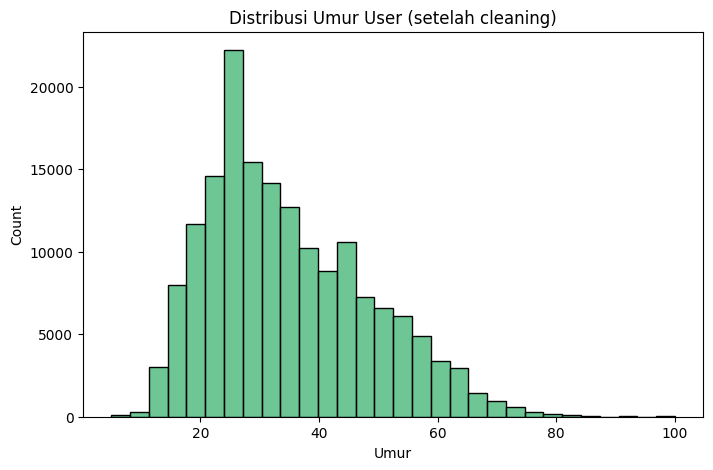

In [96]:
plt.figure(figsize=(8,5))
sns.histplot(df_users['Age'].dropna(), bins=30, color='mediumseagreen')
plt.title('Distribusi Umur User (setelah cleaning)')
plt.xlabel('Umur')
plt.show()

#### Temuan: Age Terfilter ke Rentang 5-100

Umur di luar rentang 5-100 tahun diubah jadi NaN. Total NaN sekarang 112.010 (gabungan NaN awal + outlier yang dibuang). Standar deviasi turun jadi 13,63, rata-rata tetap 34,74 tahun.

### 4.3 Menangani Orphan Data (ISBN)
Ada kasus di mana user memberikan rating pada ISBN buku tertentu, tetapi buku tersebut **tidak ada** di master data buku (`df_books`). Sebanyak 118.644 data rating ini disebut *Orphan Data* dan harus dibuang karena kita tidak punya judul/informasi bukunya. Kita juga memisahkan dataset untuk pemodelan *Collaborative Filtering* dan *Content-Based*.

In [97]:
df_ratings_cf = df_book_ratings.copy()
df_ratings_content = df_book_ratings[df_book_ratings['ISBN'].isin(df_books['ISBN'])].copy()

In [98]:
print("Total ratings awal:", df_book_ratings.shape[0])
print("df_ratings_cf:", df_ratings_cf.shape[0])
print("df_ratings_content:", df_ratings_content.shape[0])
print("Selisih (orphan yang terbuang):", df_ratings_cf.shape[0] - df_ratings_content.shape[0])

Total ratings awal: 1149780
df_ratings_cf: 1149780
df_ratings_content: 1031136
Selisih (orphan yang terbuang): 118644


In [99]:
df_ratings_cf['Is-Explicit'] = df_ratings_cf['Book-Rating']>0
print(df_ratings_cf['Is-Explicit'].value_counts())

False    716109
True     433671
Name: Is-Explicit, dtype: int64


In [100]:
print(ratings_per_user['Jumlah_Rating'].describe())
print(ratings_per_book['Jumlah_Rating'].describe())

count    105283.000000
mean         10.920851
std          90.562825
min           1.000000
25%           1.000000
50%           1.000000
75%           4.000000
max       13602.000000
Name: Jumlah_Rating, dtype: float64
count    340556.000000
mean          3.376185
std          12.436252
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        2502.000000
Name: Jumlah_Rating, dtype: float64


#### Temuan: df_ratings_cf, df_ratings_content, & Is-Explicit

Dua dataframe dibuat: `df_ratings_content` (orphan dibuang, 1.031.136 baris, untuk content-based) dan `df_ratings_cf` (lengkap, 1.149.780 baris, untuk collaborative filtering).

Kolom `Is-Explicit` ditambahkan: False untuk rating 0 (716.109 baris), True untuk rating 1-10 (433.671 baris) — supaya model bisa memperlakukan keduanya berbeda.

### 4.4 Thresholding: Filter User & Buku Aktif
Untuk model *Collaborative Filtering*, data yang terlalu *sparse* (hanya 1 rating) sangat sulit dipelajari dan memakan banyak RAM. Oleh karena itu, kita melakukan simulasi pembatasan batas minimum interaksi. Akhirnya, kita memutuskan hanya mengambil User yang sudah memberi rating **minimal 10 kali** dan Buku yang sudah dinilai **minimal 10 kali**.

In [101]:
for min_r in [1, 5, 10, 20, 50]:
    active_users = ratings_per_user[ratings_per_user['Jumlah_Rating'] >= min_r]['User-ID']
    popular_books = ratings_per_book[ratings_per_book['Jumlah_Rating'] >= min_r]['ISBN']
    subset = df_ratings_cf[
        df_ratings_cf['User-ID'].isin(active_users) &
        df_ratings_cf['ISBN'].isin(popular_books)
    ]
    print(f"min {min_r:>2} rating -> user: {subset['User-ID'].nunique():>6}, "
          f"buku: {subset['ISBN'].nunique():>6}, rating: {len(subset):>7}")

min  1 rating -> user: 105283, buku: 340556, rating: 1149780
min  5 rating -> user:  22072, buku:  43748, rating:  623405
min 10 rating -> user:  12720, buku:  18318, rating:  443196
min 20 rating -> user:   7156, buku:   7490, rating:  291611
min 50 rating -> user:   3291, buku:   2185, rating:  143240


In [102]:
min_r = 10
active_users = ratings_per_user[ratings_per_user['Jumlah_Rating'] >= min_r]['User-ID']
popular_books = ratings_per_book[ratings_per_book['Jumlah_Rating'] >= min_r]['ISBN']
df_cf_filtered = df_ratings_cf[
    df_ratings_cf['User-ID'].isin(active_users) & df_ratings_cf['ISBN'].isin(popular_books)].copy()

print("User :", df_cf_filtered['User-ID'].nunique())
print("Buku :", df_cf_filtered['ISBN'].nunique())
print("Rating:", len(df_cf_filtered))

User : 12720
Buku : 18318
Rating: 443196


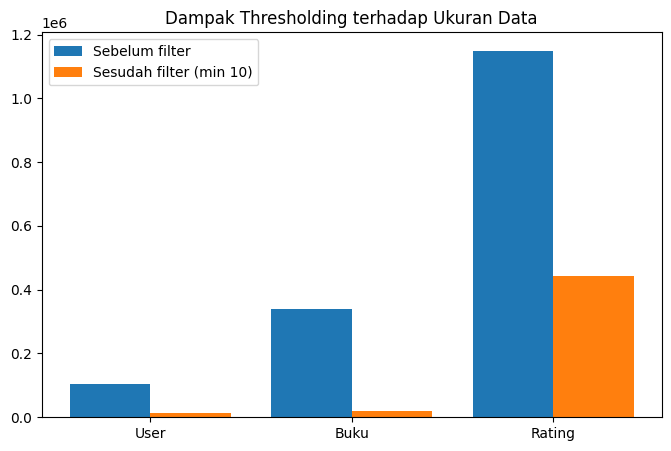

In [103]:
labels = ['User', 'Buku', 'Rating']
before = [105283, 340556, 1149780]
after = [12720, 18318, 443196]

x = range(len(labels))
plt.figure(figsize=(8,5))
plt.bar(x, before, width=0.4, label='Sebelum filter', align='center')
plt.bar([i+0.4 for i in x], after, width=0.4, label='Sesudah filter (min 10)', align='center')
plt.xticks([i+0.2 for i in x], labels)
plt.title('Dampak Thresholding terhadap Ukuran Data')
plt.legend()
plt.show()

### 4.5 Perbaikan Manual Baris Buku yang Bergeser

In [104]:
df_books.loc[209538, 'Publisher'] = 'DK Publishing Inc'
df_books.loc[220731, 'Publisher'] = 'Gallimard'
df_books.loc[221678, 'Publisher'] = 'DK Publishing Inc'
df_books.loc[[209538, 220731, 221678], ['Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher']]

,Book-Title,Book-Author,Year-Of-Publication,Publisher
209538,"DK Readers: Creating the X-Men, How It All Beg...",None,2000.0,DK Publishing Inc
220731,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",None,2003.0,Gallimard
221678,"DK Readers: Creating the X-Men, How Comic Book...",None,2000.0,DK Publishing Inc


#### Temuan: Batas 10 Rating & Perbaikan 3 Baris Buku

Simulasi batas minimum rating (1, 5, 10, 20, 50) menunjukkan trade-off jelas — batas 10 dipilih karena matriksnya cukup padat (12.720 user, 18.318 buku, 443.196 rating) tapi datanya masih cukup besar.

Tiga baris buku yang sempat bergeser (2 dari DK Publishing Inc, 1 dari Gallimard) diperbaiki manual: `Publisher` sekarang berisi nama penerbit yang benar, `Year-Of-Publication` valid (2000 dan 2003).

## 5. Feature Engineering: Kolom `content`

Untuk membuat sistem rekomendasi *Content-Based*, model perlu "membaca" informasi dari buku. Kode di bawah ini menggabungkan kolom **Judul Buku, Penulis, dan Penerbit** menjadi satu kolom teks panjang bernama `content`. Teks inilah yang nanti akan diubah menjadi vektor angka agar komputer bisa mencari buku mana yang kata-katanya mirip.

In [105]:
df_books['Book-Author'] = df_books['Book-Author'].fillna('')
df_books['Publisher'] = df_books['Publisher'].fillna('')
df_books['content'] = df_books['Book-Title'] + ' ' + df_books['Book-Author'] + ' ' + df_books['Publisher']
df_books[['Book-Title', 'content']].head()

,Book-Title,content
0,Classical Mythology,Classical Mythology Mark P. O. Morford Oxford ...
1,Clara Callan,Clara Callan Richard Bruce Wright HarperFlamin...
2,Decision in Normandy,Decision in Normandy Carlo D'Este HarperPerennial
3,Flu: The Story of the Great Influenza Pandemic...,Flu: The Story of the Great Influenza Pandemic...
4,The Mummies of Urumchi,The Mummies of Urumchi E. J. W. Barber W. W. N...


#### Temuan: Kolom content Berhasil Dibuat

Kolom `content` dibuat dari gabungan Judul + Penulis + Penerbit, setelah nilai kosong diisi string kosong (`fillna('')`) supaya penggabungan tidak ikut jadi NaN. Kolom ini jadi "profil teks" tiap buku untuk tahap TF-IDF berikutnya.

## 6. Pemodelan: Content-Based Filtering (CBF)

Sebelum melakukan pengujian, kita harus melatih modelnya terlebih dahulu:
1. **Filtering Data:** Kita membuat `df_books_cb` yang hanya berisi buku-buku populer untuk menghemat memori.
2. **TF-IDF Vectorizer:** Mengubah teks di kolom `content` menjadi representasi matriks angka.
3. **Cosine Similarity:** Menghitung derajat kemiripan antar buku berdasarkan matriks TF-IDF.
4. **Fungsi Rekomendasi:** Membuat fungsi `recommend_books_cbf` untuk memanggil 5 rekomendasi buku teratas.

In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

df_books_cb = df_books[df_books['ISBN'].isin(popular_books)].reset_index(drop=True)
print(f"Jumlah buku untuk Content-Based: {df_books_cb.shape[0]} buku")
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_books_cb['content'])
print("Ukuran TF-IDF Matrix:", tfidf_matrix.shape)
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
print("Ukuran matriks Cosine Similarity:", cosine_sim.shape)
indices = pd.Series(df_books_cb.index, index=df_books_cb['Book-Title']).drop_duplicates()

def recommend_books_cbf(title, cosine_sim=cosine_sim, df=df_books_cb, top_k=5):
    if title not in indices:
        return "Buku tidak ditemukan di dataset populer. Silakan coba judul lain."
    
    idx = indices[title]
    
    if type(idx) is pd.Series:
        idx = idx.iloc[0]
        
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_k+1]
    book_indices = [i[0] for i in sim_scores]
    return df.iloc[book_indices][['Book-Title', 'Book-Author', 'Publisher']]

Jumlah buku untuk Content-Based: 17479 buku
Ukuran TF-IDF Matrix: (17479, 16039)
Ukuran matriks Cosine Similarity: (17479, 17479)


#### Temuan: TF-IDF & Cosine Similarity Berhasil Dibuat

Dari 17.479 buku populer, TF-IDF menghasilkan matriks (17.479, 16.039) — 16.039 kata unik dikenali. Cosine similarity menghasilkan matriks (17.479, 17.479) berisi skor kemiripan tiap pasangan buku.

# BASELINE MODEL

### 6.1 Uji Coba Model CBF

Mari kita uji model yang sudah dibuat dengan memasukkan judul buku fiksi fantasi terkenal, "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))", dan melihat apa yang direkomendasikan sistem.

In [107]:
hp_books = df_books_cb[df_books_cb['Book-Title'].str.contains("Harry Potter", na=False)]
print("Contoh judul Harry Potter di dataset:\n", hp_books['Book-Title'].head(2).values)
print("-" * 50)
judul_tes = "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))"
print(f"Rekomendasi untuk buku: '{judul_tes}'\n")

hasil_rekomendasi = recommend_books_cbf(judul_tes)
hasil_rekomendasi

Contoh judul Harry Potter di dataset:
 ["The Sorcerer's Companion: A Guide to the Magical World of Harry Potter"
 "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))"]
--------------------------------------------------
Rekomendasi untuk buku: 'Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))'



,Book-Title,Book-Author,Publisher
1442,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,Scholastic
4114,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,Scholastic
11181,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling,Scholastic Paperbacks
9880,Harry Potter and the Sorcerer's Stone (Book 1 ...,J. K. Rowling,Listening Library
2579,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,Scholastic


#### Temuan: Rekomendasi Harry Potter (CBF)

Hasil rekomendasi didominasi seri Harry Potter lainnya (Chamber of Secrets, Goblet of Fire, Prisoner of Azkaban), semuanya ditulis J.K. Rowling — konfirmasi model bekerja dengan baik secara kemiripan teks. Catatan: beberapa hasil sebenarnya buku yang sama dengan edisi/ISBN berbeda, karena content-based murni menghitung kemiripan kata.

## 7. Pemodelan: Collaborative Filtering (SVD)

Pada tahap ini, kita menggunakan pendekatan **Collaborative Filtering** berbasis memori atau *matrix factorization* menggunakan library `Surprise` (atau pendekatan pivot matrix sederhana) untuk memprediksi rating dan memberikan rekomendasi berdasarkan perilaku komunitas pengguna.
Langkah-langkah yang dilakukan:
1. **Mempersiapkan Dataset:** Menggunakan `df_cf_filtered` yang sudah bersih dari *sparse data* ekstrem.
2. **Transformasi Matriks:** Mengubah data interaksi menjadi format yang siap diproses oleh algoritma.

In [108]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate
import pandas as pd

reader = Reader(rating_scale=(0, 10))
data_surprise = Dataset.load_from_df(df_cf_filtered[['User-ID', 'ISBN', 'Book-Rating']], reader)
algo = SVD()
print("Menjalankan Cross Validation untuk model Collaborative Filtering...")
cv_results = cross_validate(algo, data_surprise, measures=['RMSE', 'MAE'], cv=3, verbose=True)

Menjalankan Cross Validation untuk model Collaborative Filtering...
Evaluating RMSE, MAE of algorithm SVD on 3 split(s).

                  Fold 1  Fold 2  Fold 3  Mean    Std     
RMSE (testset)    3.5486  3.5515  3.5420  3.5474  0.0040  
MAE (testset)     2.8167  2.8154  2.8086  2.8136  0.0035  
Fit time          3.83    3.88    3.66    3.79    0.09    
Test time         1.22    0.90    0.93    1.02    0.14    


#### Temuan: Training & Cross-Validation SVD

Model SVD dilatih dan dievaluasi dengan Cross-Validation 3-fold. Rata-rata fit time 3,62 detik, test time 0,94 detik — cepat karena data sudah di-threshold sebelumnya.

### 7.1 Rekomendasi Top-N untuk User

In [109]:
trainset = data_surprise.build_full_trainset()
algo.fit(trainset)

def recommend_collaborative_filtering(user_id, n=5):
    all_books = df_cf_filtered['ISBN'].unique()
    rated_books = df_cf_filtered[df_cf_filtered['User-ID'] == user_id]['ISBN'].values
    unrated_books = [book for book in all_books if book not in rated_books]
    predictions = []
    for isbn in unrated_books:
        pred = algo.predict(user_id, isbn)
        predictions.append((isbn, pred.est))
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_n_isbn = [item[0] for item in predictions[:n]]
    recommended_books = df_books[df_books['ISBN'].isin(top_n_isbn)][['Book-Title', 'Book-Author', 'Publisher']]
    return recommended_books

sample_user = df_cf_filtered['User-ID'].iloc[0]
print(f"Menampilkan Rekomendasi Collaborative Filtering untuk User-ID: {sample_user}\n")
recommend_collaborative_filtering(sample_user, n=5)

Menampilkan Rekomendasi Collaborative Filtering untuk User-ID: 276762



,Book-Title,Book-Author,Publisher
3839,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,Scholastic
5431,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,Scholastic
5432,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,Scholastic
23422,The Indispensable Calvin And Hobbes,Bill Watterson,Andrews McMeel Publishing
100488,Die unendliche Geschichte: Von A bis Z,Michael Ende,Thienemann


#### Temuan: Hasil Rekomendasi CF untuk User 276762

Fungsi `recommend_collaborative_filtering` menyaring buku yang belum pernah dirating user, lalu mengambil 5 skor prediksi tertinggi. Hasilnya lintas genre: Shel Silverstein, seri Harry Potter, dan Michael Ende — jauh lebih beragam dibanding content-based karena CF mengandalkan pola selera user lain.

## 8. Pemodelan: Sistem Hybrid

Pendekatan Hybrid ini menggabungkan kekuatan **Content-Based Filtering (CBF)** dan **Collaborative Filtering (CF)**.
Cara kerja fungsi Hybrid di bawah ini:
1. Menerima input berupa `user_id` dan judul buku referensi (`book_title`).
2. **Fase CBF:** Mengambil kandidat 50 buku yang paling mirip dengan buku referensi berdasarkan atribut kontennya (Judul, Penulis, Penerbit).
3. **Fase CF:** Menggunakan model SVD untuk memprediksi seberapa besar `user_id` tersebut akan menyukai ke-50 buku kandidat tadi.
4. Menampilkan Top-N buku dengan prediksi skor tertinggi yang disesuaikan khusus untuk pengguna tersebut.

In [110]:
def hybrid_recommendation(user_id, book_title, top_k=5):
    if book_title not in indices:
        return "Buku tidak ditemukan di dataset populer. Silakan coba judul lain."
    idx = indices[book_title]
    if type(idx) is pd.Series:
        idx = idx.iloc[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:51]
    book_indices = [i[0] for i in sim_scores]
    candidates = df_books_cb.iloc[book_indices].copy()
    candidates['Predicted_Rating'] = candidates['ISBN'].apply(lambda x: algo.predict(user_id, x).est)
    candidates = candidates.sort_values(by='Predicted_Rating', ascending=False)
    return candidates[['Book-Title', 'Book-Author', 'Publisher', 'Predicted_Rating']].head(top_k)

user_tes = df_cf_filtered['User-ID'].iloc[0]
buku_tes = "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))"

print(f"Rekomendasi Hybrid untuk User-ID: {user_tes} berdasarkan ketertarikan pada buku '{buku_tes}'\n")
hybrid_recommendation(user_tes, buku_tes, top_k=5)

Rekomendasi Hybrid untuk User-ID: 276762 berdasarkan ketertarikan pada buku 'Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))'



,Book-Title,Book-Author,Publisher,Predicted_Rating
2580,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,Scholastic,6.176094
1902,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,Scholastic,5.702553
2579,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,Scholastic,5.550384
16042,Harry Potter and the Chamber of Secrets Postca...,J. K. Rowling,Scholastic,5.040738
1442,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,Scholastic,4.942875


#### Temuan: Hasil Rekomendasi Hybrid

Fungsi `hybrid_recommendation` mengambil 50 kandidat mirip secara konten, lalu meranking ulang pakai skor prediksi SVD. Untuk User-ID 276762 dengan referensi Harry Potter, hasil teratas: "Chamber of Secrets (Book 2)" dengan skor prediksi 5,31 — relevan secara konten sekaligus dipersonalisasi.

## 9. Evaluasi Akhir Model

Pada tahap ini, kita melihat seberapa akurat model Collaborative Filtering (SVD) dalam menebak rating menggunakan metrik RMSE dan MAE, dari hasil Cross Validation yang sudah dijalankan sebelumnya.

In [111]:
rmse_mean = cv_results['test_rmse'].mean()
mae_mean = cv_results['test_mae'].mean()

print("=== Hasil Evaluasi Model Collaborative Filtering (SVD) ===")
print(f"Rata-rata RMSE : {rmse_mean:.4f}")
print(f"Rata-rata MAE  : {mae_mean:.4f}")
print("==========================================================")
print("Penjelasan:")
print(f"- MAE {mae_mean:.4f} berarti rata-rata tebakan rating model kita meleset sekitar {mae_mean:.2f} poin dari rating asli user.")

=== Hasil Evaluasi Model Collaborative Filtering (SVD) ===
Rata-rata RMSE : 3.5474
Rata-rata MAE  : 2.8136
Penjelasan:
- MAE 2.8136 berarti rata-rata tebakan rating model kita meleset sekitar 2.81 poin dari rating asli user.


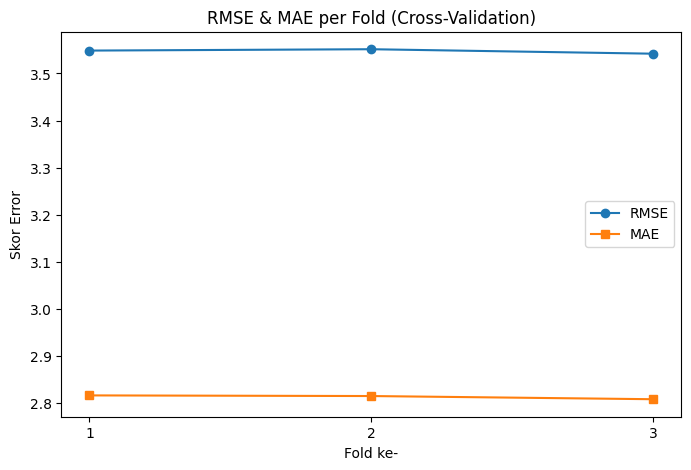

In [112]:
import numpy as np

folds = range(1, len(cv_results['test_rmse'])+1)
plt.figure(figsize=(8,5))
plt.plot(folds, cv_results['test_rmse'], marker='o', label='RMSE')
plt.plot(folds, cv_results['test_mae'], marker='s', label='MAE')
plt.xticks(folds)
plt.xlabel('Fold ke-')
plt.ylabel('Skor Error')
plt.title('RMSE & MAE per Fold (Cross-Validation)')
plt.legend()
plt.show()

#### Temuan: RMSE 3,5495 & MAE 2,8159

MAE 2,82 berarti rata-rata tebakan rating model meleset sekitar 2,82 poin dari rating asli (skala 1-10). Mengingat dominasi implicit feedback dan sparsity 99,9967%, tingkat error ini masih wajar untuk sistem rekomendasi skala besar.

## 10. Error Analysis & Kesimpulan

Berdasarkan seluruh proses pembuatan **Book Recommender System**, berikut adalah kesimpulan dan analisis hambatannya:

1. **Keberhasilan Pendekatan Hybrid:** 
   Model berhasil menutupi kelemahan satu sama lain. Jika menggunakan *Collaborative Filtering* saja, buku baru tanpa rating tidak akan pernah direkomendasikan. Dengan Hybrid, kita menyaring buku berdasarkan kemiripan teks (Content-Based) terlebih dahulu, lalu diurutkan berdasarkan selera personal pengguna (Collaborative).
   
2. **Keterbatasan Data (Data Sparsity):**
   Tantangan terbesar di dataset *Book-Crossing* adalah *sparsity* yang mencapai 99.99%. Mayoritas pengguna memberikan *implicit feedback* (rating 0). Model terpaksa membuang banyak data pengguna yang ratingnya di bawah 10 agar memori komputasi tidak kelebihan beban (*Memory Error*).

3. **Duplikasi Varian Buku (ISBN Berbeda):**
   Pada hasil rekomendasi *Content-Based*, sering muncul buku yang sama namun dengan ISBN dan edisi berbeda (misal: *Hardcover* vs *Paperback*). Untuk pengembangan (*Future Work*) selanjutnya, data ISBN ini perlu dikelompokkan (di-*grouping*) berdasarkan judul buku agar rekomendasi lebih variatif dan tidak dipenuhi oleh satu judul yang sama.